In [6]:
# CIFAR10 dataset으로 분류기 작성 + CNN 레이어 추가

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.callbacks import EarlyStopping

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape, y_train.shape) # (50000, 32, 32, 3) (50000, 1)
print(x_test.shape, y_test.shape) # (10000, 32, 32, 3) (10000, 1)

# 정규화
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

# 원핫인코딩
NUM_CLASSES = 10
y_train = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test = to_categorical(y_test, num_classes=NUM_CLASSES)

(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


In [7]:
# 모델 정의
def conv_block(x, filters):
  x = layers.Conv2D(filters, kernel_size= 3, padding='same', use_bias=False,)(x)
  x = layers.BatchNormalization()(x)
  x = layers.ReLU()(x)
  return x

inputs = layers.Input(shape=(32, 32, 3))
# stage 1
x = conv_block(inputs, 32)
x = conv_block(x, 32)
x = layers.MaxPooling2D()(x)

# stage 2
x = conv_block(x, 64)
x = conv_block(x, 64)
x = layers.MaxPooling2D()(x)

# stage 3
x = conv_block(x, 128)
x = conv_block(x, 128)
x = layers.MaxPooling2D()(x)

# 분류기
x = layers.GlobalAveragePooling2D()(x)  # 4차원을 2차원으로 줄여주기 때문에 Flatten 사용할 필요없음.
                                        # CNN의 마지막 conv 출력이 (batch_size, w, w, c)형태인데 이를 채널 평균값을 하나씩 뽑는 방식 사용
                                        # 장점 : 파라미터 수가 줄어든다. 과적합 방지에 효과적

x = layers.Dropout(rate=0.2)(x)
x = layers.Dense(units=128, activation='relu')(x)
x = layers.Dropout(rate=0.2)(x)

outputs = layers.Dense(units=10, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs, name='cifar10_cnn')
model.summary()




Model: "cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             

 Total params: 306,154 (1.17 MB)

 Trainable params: 305,258 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/100
352/352 - 17s - 48ms/step - accuracy: 0.9800 - loss: 0.0581 - val_accuracy: 0.7564 - val_loss: 1.3496
Epoch 2/100
352/352 - 5s - 15ms/step - accuracy: 0.9811 - loss: 0.0559 - val_accuracy: 0.8086 - val_loss: 0.9703
Epoch 3/100
352/352 - 5s - 15ms/step - accuracy: 0.9820 - loss: 0.0526 - val_accuracy: 0.7872 - val_loss: 1.0873
Epoch 4/100
352/352 - 5s - 15ms/step - accuracy: 0.9835 - loss: 0.0479 - val_accuracy: 0.7982 - val_loss: 1.1648
Epoch 5/100
352/352 - 5s - 15ms/step - accuracy: 0.9835 - loss: 0.0476 - val_accuracy: 0.7898 - val_loss: 1.1589
Epoch 6/100
352/352 - 5s - 15ms/step - accuracy: 0.9835 - loss: 0.0498 - val_accuracy: 0.8090 - val_loss: 1.0301
Epoch 7/100
352/352 - 5s - 15ms/step - accuracy: 0.9860 - loss: 0.0419 - val_accuracy: 0.8188 - val_loss: 0.8914
Epoch 8/100
352/352 - 5s - 15ms/step - accuracy: 0.9836 - loss: 0.0469 - val_accuracy: 0.7982 - val_loss: 1.0919
Epoch 9/100
352/352 - 5s - 15ms/step - accuracy: 0.9842 - loss: 0.0466 - val_accuracy: 0.8028 -

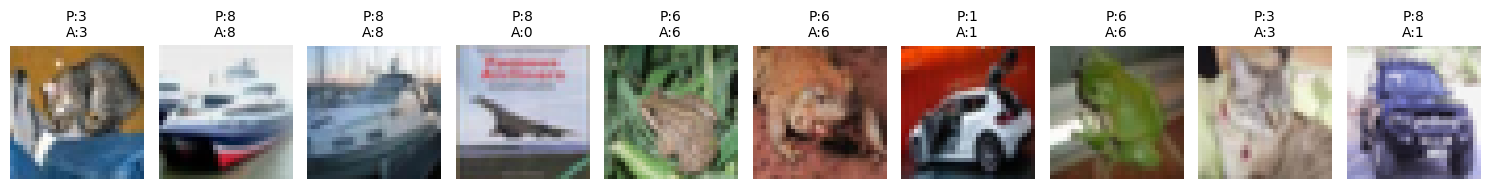

In [11]:
# compile / fit
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

es = EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True)

history = model.fit(x=x_train, y=y_train, batch_size=128, epochs=100, verbose=2, validation_split=0.1, shuffle=True, callbacks=[es])

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0, batch_size=128)
print("test acc : %.4f"%(test_acc))
print("test loss : %.4f"%(test_loss))

# Get predictions for visualization
predictions = model.predict(x_test)
pred = np.argmax(predictions, axis=1) # Predicted classes
actual = np.argmax(y_test, axis=1)    # Actual classes

# 시각화
fig = plt.figure(figsize=(15, 3))
fig.subplots_adjust(hspace=0.4, wspace=0.4)
for i in range(10):
    img = x_test[i]
    ax = fig.add_subplot(1, 10, i + 1)
    ax.axis('off')
    ax.imshow(img)
    ax.set_title(f'P:{pred[i]}\nA:{actual[i]}', fontsize=10)

plt.tight_layout()
plt.show()